In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
y=pd.read_csv('D:/IC/Microdados_2010-2021/microdados_enem_2009/DADOS/ITENS_PROVA_2009.csv',sep=';', encoding = "ISO-8859-1")

In [12]:
Matematica = y.query("SG_AREA=='MT'")
#Analisando=Analisando.query(f"IN_ITEM_ABAN==0")
mat_A=Matematica.query(f'CO_PROVA==61')
mat_AZ=Matematica.query(f'CO_PROVA==62')
mat_C=Matematica.query(f'CO_PROVA==63')
mat_R=Matematica.query(f'CO_PROVA==64')
Analisando=pd.concat([mat_A,mat_AZ,mat_C,mat_R])

In [14]:
maior=Analisando['NU_PARAM_B'].max()
Analisando.query(f'NU_PARAM_B=={maior}')

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,IN_ITEM_ABAN,TX_MOTIVO_ABAN,NU_PARAM_A,NU_PARAM_B,NU_PARAM_C,TX_COR,CO_PROVA
1368,172,MT,60262.0,C,25.0,0,NaN,1.05092,4.28177,0.21068,AMARELO,61
1369,172,MT,60262.0,C,25.0,0,NaN,1.05092,4.28177,0.21068,CINZA,62
1370,172,MT,60262.0,C,25.0,0,NaN,1.05092,4.28177,0.21068,AZUL,63
1371,172,MT,60262.0,C,25.0,0,NaN,1.05092,4.28177,0.21068,ROSA,64


In [20]:
mat_A.query(f'CO_HABILIDADE=={25}')['CO_POSICAO']#-136

1336    168
1368    172
Name: CO_POSICAO, dtype: int64

In [24]:
mat_A.query(f'CO_POSICAO=={168}')

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,IN_ITEM_ABAN,TX_MOTIVO_ABAN,NU_PARAM_A,NU_PARAM_B,NU_PARAM_C,TX_COR,CO_PROVA
1336,168,MT,60259.0,E,25.0,0,NaN,4.03232,2.25593,0.08861,AMARELO,61


In [25]:
mat_AZ.query(f'CO_POSICAO=={167}')

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,IN_ITEM_ABAN,TX_MOTIVO_ABAN,NU_PARAM_A,NU_PARAM_B,NU_PARAM_C,TX_COR,CO_PROVA
1329,167,MT,60259.0,E,25.0,0,NaN,4.03232,2.25593,0.08861,CINZA,62


In [22]:
mat_AZ.query(f'CO_HABILIDADE=={25}')['CO_POSICAO']#-136

1329    167
1369    172
Name: CO_POSICAO, dtype: int64

In [26]:
menor=Analisando['NU_PARAM_B'].min()
Analisando.query(f'NU_PARAM_B=={menor}')

,CO_POSICAO,SG_AREA,CO_ITEM,TX_GABARITO,CO_HABILIDADE,IN_ITEM_ABAN,TX_MOTIVO_ABAN,NU_PARAM_A,NU_PARAM_B,NU_PARAM_C,TX_COR,CO_PROVA
1184,149,MT,59484.0,E,7.0,0,NaN,1.01912,-0.96661,0.0063,AMARELO,61
1185,149,MT,59484.0,E,7.0,0,NaN,1.01912,-0.96661,0.0063,CINZA,62
1186,149,MT,59484.0,E,7.0,0,NaN,1.01912,-0.96661,0.0063,AZUL,63
1187,149,MT,59484.0,E,7.0,0,NaN,1.01912,-0.96661,0.0063,ROSA,64


In [27]:
mat_A.query(f'CO_HABILIDADE=={7}')['CO_POSICAO']

1184    149
Name: CO_POSICAO, dtype: int64

In [10]:
x=pd.read_csv("D:/IC/Microdados_2010-2021/microdados_enem_2009/DADOS/MICRODADOS_ENEM_2009.csv",
                  sep=";",encoding='ISO-8859-1',usecols=['TP_ST_CONCLUSAO','TP_PRESENCA_CN','TP_PRESENCA_MT','TP_PRESENCA_CH',
                                                         'TP_PRESENCA_LC','TP_STATUS_REDACAO','NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC',
                                                         'NU_NOTA_MT','TP_STATUS_REDACAO','NU_NOTA_REDACAO','TX_RESPOSTAS_MT',
                                                         'CO_PROVA_MT','TX_GABARITO_MT','CO_PROVA_MT','TP_SEXO'])

In [11]:
n=16587
Amostra=x.sample(n, replace=False )

a=Amostra.query(f'TP_PRESENCA_CN==1')
b=a.query(f'TP_PRESENCA_MT==1')
c=b.query(f'TP_PRESENCA_CH==1')
d=c.query(f'TP_PRESENCA_LC==1')
e=d.query(f'TP_STATUS_REDACAO=="P"')

f=e.query(f'CO_PROVA_MT=={61}')
g=e.query(f'CO_PROVA_MT=={62}')
h=e.query(f'CO_PROVA_MT=={63}')
i=e.query(f'CO_PROVA_MT=={64}')
guard=pd.concat([f,g,h,i])

pre_universitario=guard.query(f'TP_ST_CONCLUSAO!=4')
pre_universitarios=pre_universitario.query(f'TP_ST_CONCLUSAO!=3')
Colunas=['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
dados=pre_universitarios.filter(Colunas)

In [12]:
dados

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
423480,476.7,442.3,426.9,430.0,350
1907255,490.9,525.6,572.0,528.6,625
3137671,438.5,403.3,485.3,478.4,675
1252331,449.0,307.6,366.0,462.3,725
1014974,538.6,545.4,540.5,467.2,650
...,...,...,...,...,...
3008715,486.2,465.1,563.4,462.1,800
4130677,449.8,391.6,459.3,434.4,650
1145674,415.2,372.9,429.2,370.0,475
501163,760.1,739.3,801.8,566.5,400


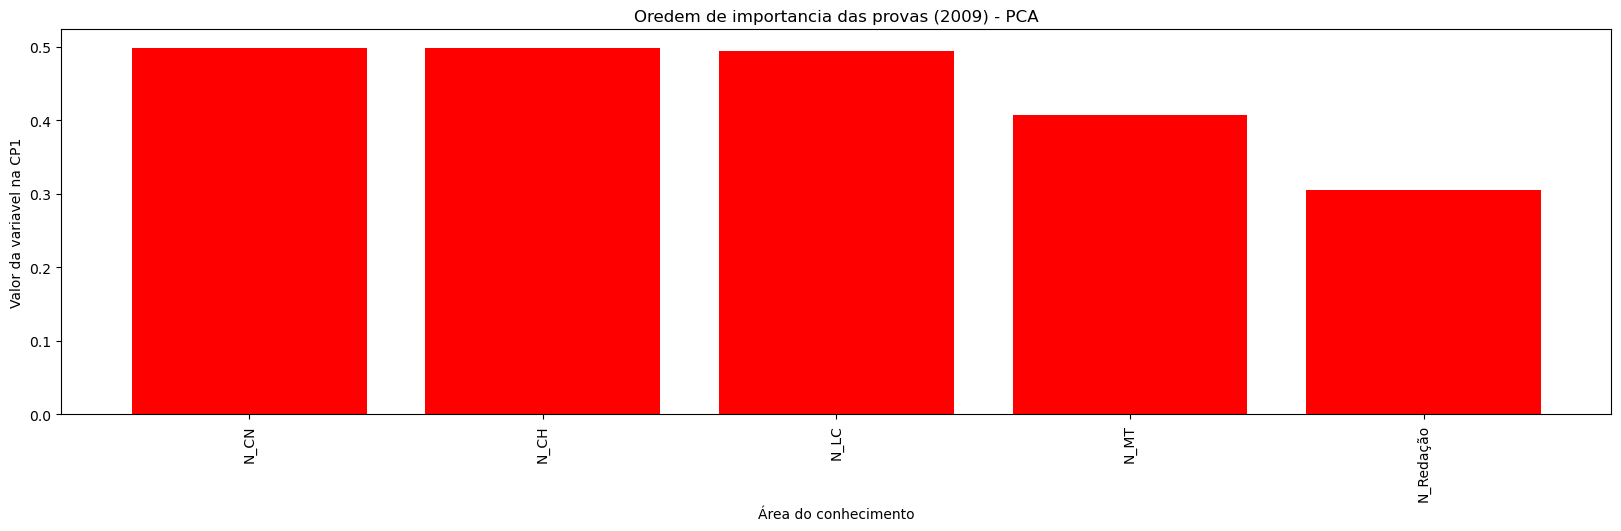

[0.49843322 0.4978699  0.49452495 0.40728107 0.30538024]


In [13]:
scaling=StandardScaler()

scaling.fit(dados)
Scaled_data=scaling.transform(dados)
n=5
principal=PCA(n_components=n)
principal.fit(Scaled_data)
x=principal.transform(Scaled_data)
#(principal.explained_variance_ratio_)
#print(x.shape)

Prova=['N_CN', 'N_CH', 'N_LC', 'N_MT', 'N_Redação']
#Prova=[1,2,3,4,5]    

CP1 = abs(principal.components_[0])
df = pd.DataFrame(CP1, columns=['CP1'])

df['Prova'] = Prova

#df2=pd.concat([df,df1])

df2_ord=df.sort_values(by=['CP1'],ascending=False)

plt.figure (figsize = (20, 5))
plt.bar(df2_ord['Prova'],df2_ord['CP1'], color="red")

plt.xlabel('Área do conhecimento')
plt.ylabel('Valor da variavel na CP1')
plt.title('Oredem de importancia das provas (2009) - PCA')

plt.xticks(rotation=90)
plt.show()

print(CP1)

In [16]:
x=pd.read_csv("D:/IC/Microdados_2010-2021/microdados_enem_2010/DADOS/MICRODADOS_ENEM_2010.csv",
                  sep=";",encoding='ISO-8859-1',usecols=['TP_ST_CONCLUSAO','TP_PRESENCA_CN','TP_PRESENCA_MT','TP_PRESENCA_CH',
                                                         'TP_PRESENCA_LC','TP_STATUS_REDACAO','NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC',
                                                         'NU_NOTA_MT','TP_STATUS_REDACAO','NU_NOTA_REDACAO','TX_RESPOSTAS_MT',
                                                         'CO_PROVA_MT','TX_GABARITO_MT','CO_PROVA_MT','TP_SEXO'])

In [17]:
n=16587
Amostra=x.sample(n, replace=False )

a=Amostra.query(f'TP_PRESENCA_CN==1')
b=a.query(f'TP_PRESENCA_MT==1')
c=b.query(f'TP_PRESENCA_CH==1')
d=c.query(f'TP_PRESENCA_LC==1')
e=d.query(f'TP_STATUS_REDACAO=="P"')

F=d.query(f'CO_PROVA_MT=={97}')
G=d.query(f'CO_PROVA_MT=={98}')
H=d.query(f'CO_PROVA_MT=={99}')
I=d.query(f'CO_PROVA_MT=={100}')
guard=pd.concat([F,G,H,I])
#guard=pd.concat([a,b,c,d])

pre_universitario=guard.query(f'TP_ST_CONCLUSAO!=4')
pre_universitarios=pre_universitario.query(f'TP_ST_CONCLUSAO!=3')
Colunas=['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
dados=pre_universitarios.filter(Colunas)

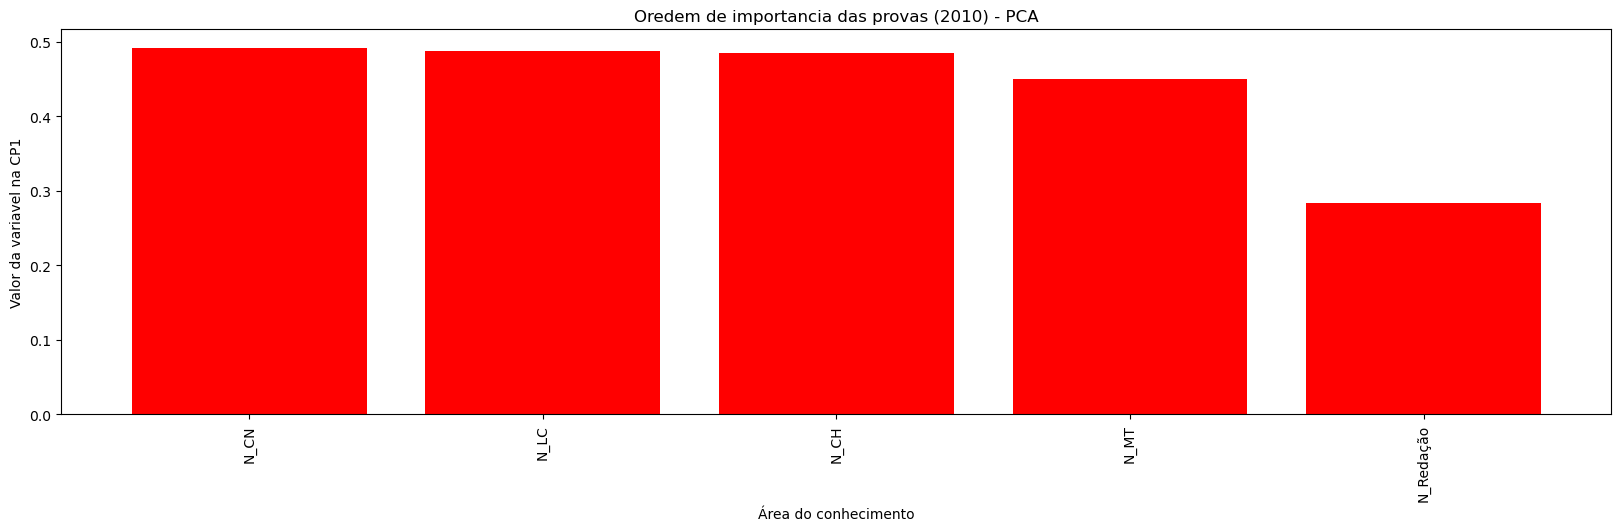

[0.49213325 0.48582098 0.4879659  0.45062594 0.28391616]


In [18]:
scaling=StandardScaler()

scaling.fit(dados)
Scaled_data=scaling.transform(dados)
n=5
principal=PCA(n_components=n)
principal.fit(Scaled_data)
x=principal.transform(Scaled_data)
#(principal.explained_variance_ratio_)
#print(x.shape)

Prova=['N_CN', 'N_CH', 'N_LC', 'N_MT', 'N_Redação']
#Prova=[1,2,3,4,5]    

CP1 = abs(principal.components_[0])
df = pd.DataFrame(CP1, columns=['CP1'])

df['Prova'] = Prova

#df2=pd.concat([df,df1])

df2_ord=df.sort_values(by=['CP1'],ascending=False)

plt.figure (figsize = (20, 5))
plt.bar(df2_ord['Prova'],df2_ord['CP1'], color="red")

plt.xlabel('Área do conhecimento')
plt.ylabel('Valor da variavel na CP1')
plt.title('Oredem de importancia das provas (2010) - PCA')

plt.xticks(rotation=90)
plt.show()

print(CP1)

In [19]:
x=pd.read_csv("D:/IC/Microdados_2010-2021/microdados_enem_2011/DADOS/MICRODADOS_ENEM_2011.csv",
                  sep=";",encoding='ISO-8859-1',usecols=['TP_ST_CONCLUSAO','TP_PRESENCA_CN','TP_PRESENCA_MT','TP_PRESENCA_CH',
                                                         'TP_PRESENCA_LC','TP_STATUS_REDACAO','NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC',
                                                         'NU_NOTA_MT','TP_STATUS_REDACAO','NU_NOTA_REDACAO','TX_RESPOSTAS_MT',
                                                         'CO_PROVA_MT','TX_GABARITO_MT','CO_PROVA_MT','TP_SEXO'])

In [20]:
n=16587
Amostra=x.sample(n, replace=False )

a=Amostra.query(f'TP_PRESENCA_CN==1')
b=a.query(f'TP_PRESENCA_MT==1')
c=b.query(f'TP_PRESENCA_CH==1')
d=c.query(f'TP_PRESENCA_LC==1')
e=d.query(f'TP_STATUS_REDACAO=="P"')

F=d.query(f'CO_PROVA_MT=={129}')
G=d.query(f'CO_PROVA_MT=={130}')
H=d.query(f'CO_PROVA_MT=={131}')
I=d.query(f'CO_PROVA_MT=={132}')
guard=pd.concat([F,G,H,I])
#guard=pd.concat([a,b,c,d])

pre_universitario=guard.query(f'TP_ST_CONCLUSAO!=4')
pre_universitarios=pre_universitario.query(f'TP_ST_CONCLUSAO!=3')
Colunas=['NU_NOTA_CN','NU_NOTA_CH','NU_NOTA_LC','NU_NOTA_MT','NU_NOTA_REDACAO']
dados=pre_universitarios.filter(Colunas)

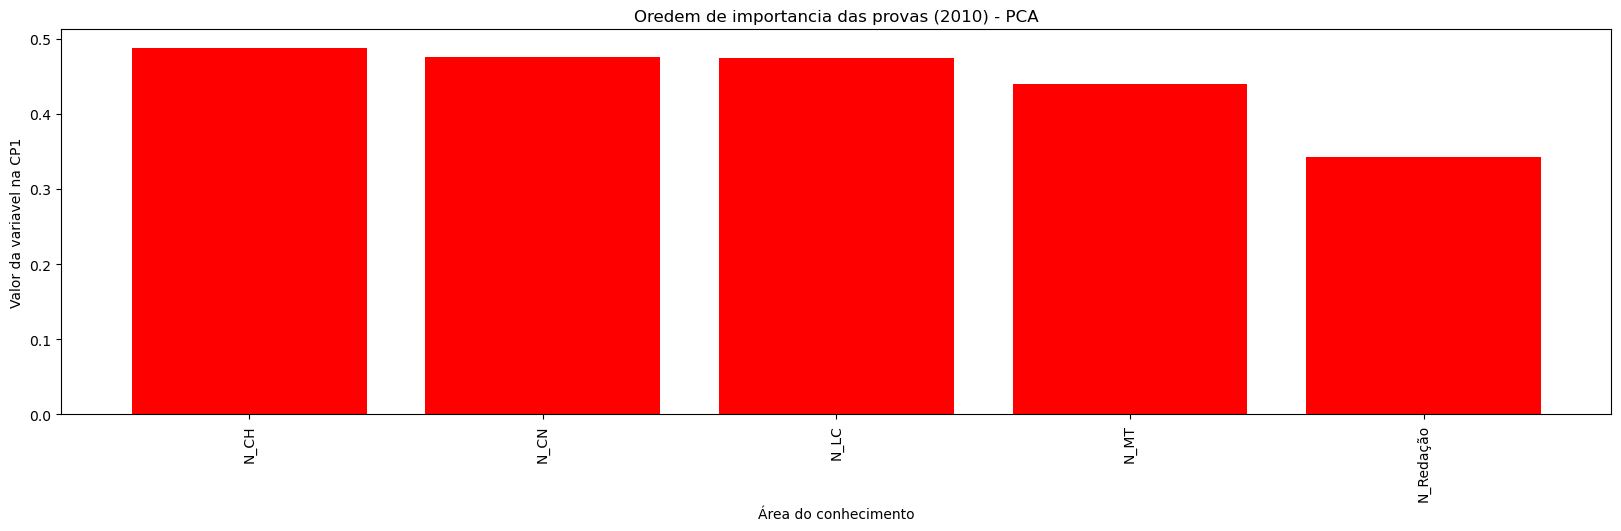

[0.47634977 0.48800372 0.4738724  0.43937802 0.34254221]


In [21]:
scaling=StandardScaler()

scaling.fit(dados)
Scaled_data=scaling.transform(dados)
n=5
principal=PCA(n_components=n)
principal.fit(Scaled_data)
x=principal.transform(Scaled_data)
#(principal.explained_variance_ratio_)
#print(x.shape)

Prova=['N_CN', 'N_CH', 'N_LC', 'N_MT', 'N_Redação']
#Prova=[1,2,3,4,5]    

CP1 = abs(principal.components_[0])
df = pd.DataFrame(CP1, columns=['CP1'])

df['Prova'] = Prova

#df2=pd.concat([df,df1])

df2_ord=df.sort_values(by=['CP1'],ascending=False)

plt.figure (figsize = (20, 5))
plt.bar(df2_ord['Prova'],df2_ord['CP1'], color="red")

plt.xlabel('Área do conhecimento')
plt.ylabel('Valor da variavel na CP1')
plt.title('Oredem de importancia das provas (2010) - PCA')

plt.xticks(rotation=90)
plt.show()

print(CP1)